In [3]:
import mysql.connector
import pandas as pd 
import numpy as numpy
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

cnx = mysql.connector.connect(
    host="127.0.0.1",
    port="3306",
    user="root",
    password = "Rahul@321"
)

In [4]:
query = "Select * FROM finance.customers"

In [5]:
df=pd.read_sql(query,cnx)


In [6]:
df.head()

,unnamed:_0,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,...,checking_accounts,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid,income_band
0,0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,...,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1,Low
1,1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,...,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2,Med
2,2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,...,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3,Med
3,3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,...,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4,High
4,4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,...,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5,Med


EDA

In [7]:
df.shape

(3000, 27)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   unnamed:_0                3000 non-null   int64  
 1   client_id                 3000 non-null   object 
 2   name                      3000 non-null   object 
 3   age                       3000 non-null   int64  
 4   location_id               3000 non-null   int64  
 5   joined_bank               3000 non-null   object 
 6   banking_contact           3000 non-null   object 
 7   nationality               3000 non-null   object 
 8   occupation                3000 non-null   object 
 9   fee_structure             3000 non-null   object 
 10  loyalty_classification    3000 non-null   object 
 11  estimated_income          3000 non-null   float64
 12  superannuation_savings    3000 non-null   float64
 13  amount_of_credit_cards    3000 non-null   int64  
 14  credit_c

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
unnamed:_0,3000.0,1499.500000,866.169729,0.00,749.7500,1499.500,2.249250e+03,2999.00
age,3000.0,51.039667,19.854760,17.00,34.0000,51.000,6.900000e+01,85.00
location_id,3000.0,21563.323000,12462.273017,12.00,10803.5000,21129.500,3.205450e+04,43369.00
estimated_income,3000.0,171305.034263,111935.808209,15919.48,82906.5950,142313.480,2.422903e+05,522330.26
superannuation_savings,3000.0,25531.599673,16259.950770,1482.03,12513.7750,22357.355,3.546474e+04,75963.90
amount_of_credit_cards,3000.0,1.463667,0.676387,1.00,1.0000,1.000,2.000000e+00,3.00
credit_card_balance,3000.0,3176.206943,2497.094709,1.17,1236.6300,2560.805,4.522632e+03,13991.99
bank_loans,3000.0,591386.155487,457557.036334,0.00,239628.1375,479793.400,8.258130e+05,2667556.66
bank_deposits,3000.0,671560.193923,645716.856875,0.00,204400.3750,463316.460,9.427546e+05,3890598.08
checking_accounts,3000.0,321092.949127,282079.553893,0.00,119947.5300,242815.655,4.348749e+05,1969923.08


In [10]:
bins = [0,100000,300000,float('inf')]
labels =['Low','Med','High']

In [11]:
# replace 'estimated_income' with your actual column name
df['Income Band'] = pd.cut(
    df['estimated_income'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

<Axes: xlabel='Income Band'>

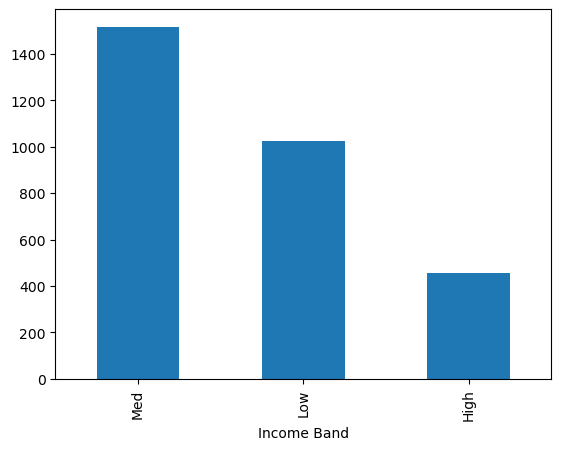

In [ ]:
df['Income Band'].value_counts().plot(kind='bar')

In [13]:
df.head(10)

,unnamed:_0,client_id,name,age,location_id,joined_bank,banking_contact,nationality,occupation,fee_structure,...,saving_accounts,foreign_currency_account,business_lending,properties_owned,risk_weighting,brid,genderid,iaid,income_band,Income Band
0,0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,...,607332.46,12249.96,1134475.30,1,2,1,1,1,Low,Low
1,1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,...,344635.16,61162.31,2000526.10,1,3,2,1,2,Med,Med
2,2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,...,203054.35,79071.78,548137.58,1,3,3,2,3,Med,Med
3,3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,...,234685.02,57513.65,1148402.29,0,4,4,1,4,High,High
4,4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,...,128351.45,30012.14,1674412.12,0,3,1,2,5,Med,Med
5,5,IND78532,Samuel Hudson,23,13204,07-02-2019,Douglas Tucker,American,Help Desk Technician,High,...,238310.37,15615.18,1556031.06,1,2,1,1,6,Med,Med
6,6,IND95683,Timothy Alexander,46,42910,02-06-2002,Douglas Tucker,Asian,Account Coordinator,High,...,24639.33,3045.78,154111.62,1,1,1,2,7,Low,Low
7,7,IND40785,Carl Martin,78,6127,03-11-2000,Steve Diaz,European,Automation Specialist II,Mid,...,46813.78,51979.19,1171456.68,0,2,2,2,8,Low,Low
8,8,IND13570,Philip Day,67,32656,07-04-2015,Bruce Butler,Asian,Software Test Engineer II,High,...,279528.12,27125.28,464560.28,0,1,2,2,9,Low,Low
9,9,IND53299,Jason Sims,51,28340,20-11-1995,Joe Price,European,Geologist III,Mid,...,115869.39,48043.52,908583.94,2,1,3,1,10,Low,Low


In [14]:
df.columns

Index(['unnamed:_0', 'client_id', 'name', 'age', 'location_id', 'joined_bank',
       'banking_contact', 'nationality', 'occupation', 'fee_structure',
       'loyalty_classification', 'estimated_income', 'superannuation_savings',
       'amount_of_credit_cards', 'credit_card_balance', 'bank_loans',
       'bank_deposits', 'checking_accounts', 'saving_accounts',
       'foreign_currency_account', 'business_lending', 'properties_owned',
       'risk_weighting', 'brid', 'genderid', 'iaid', 'income_band',
       'Income Band'],
      dtype='object')

UNIVARIENT ANALYSIS

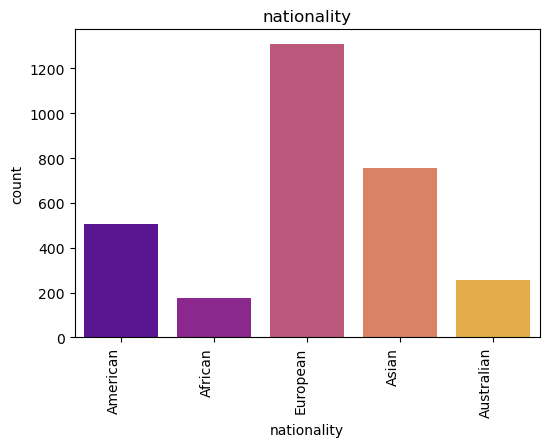

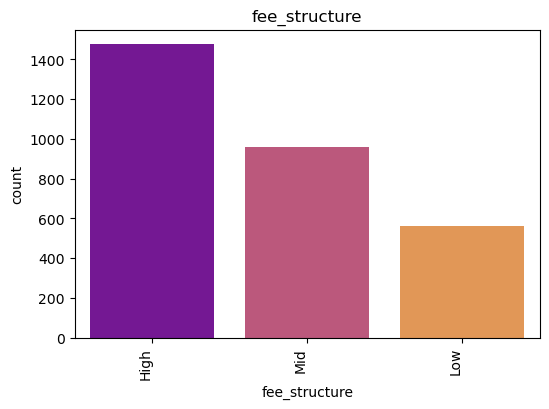

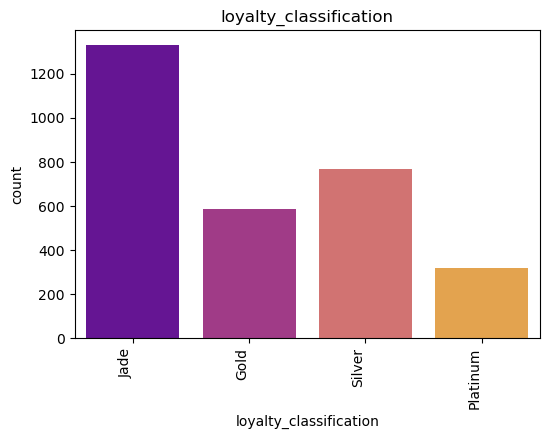

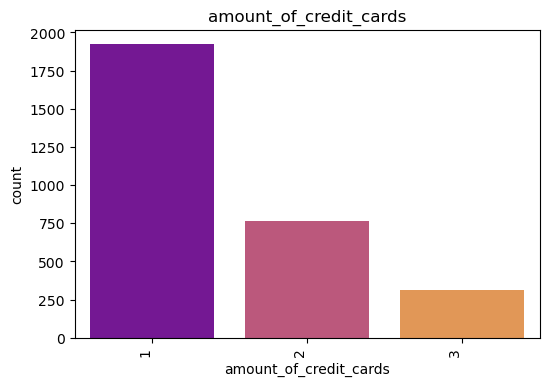

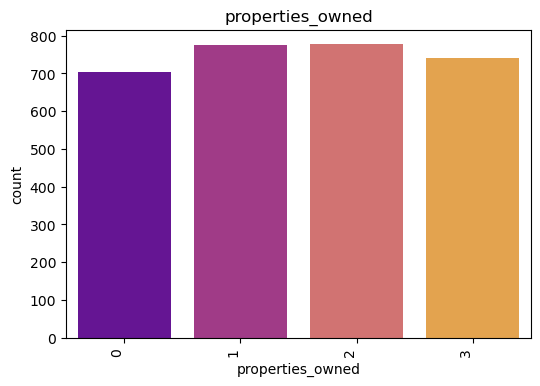

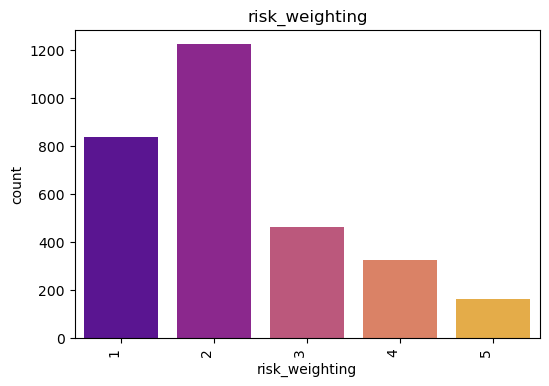

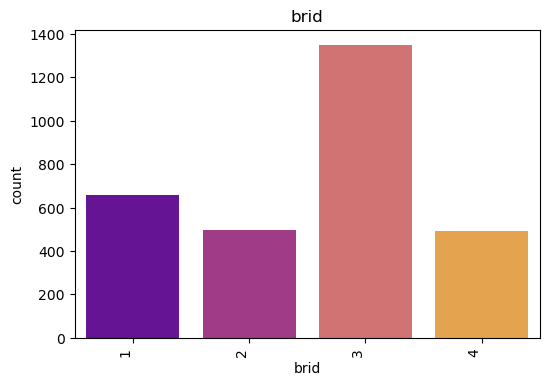

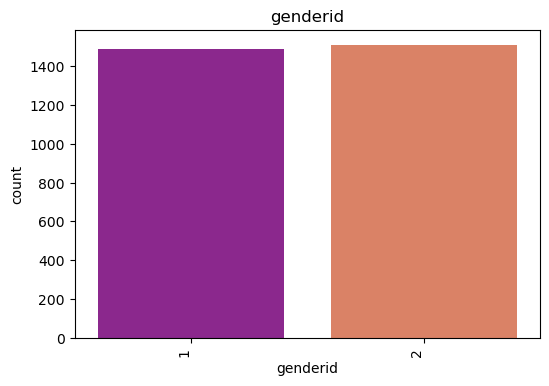

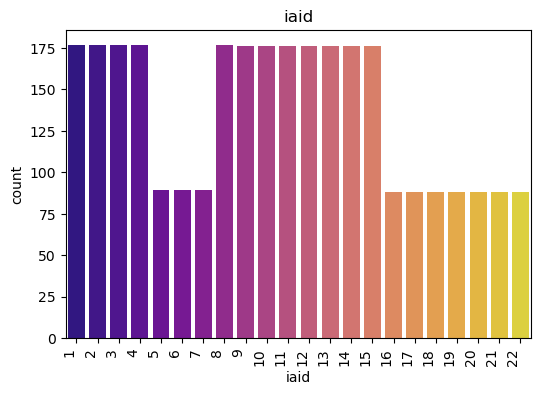

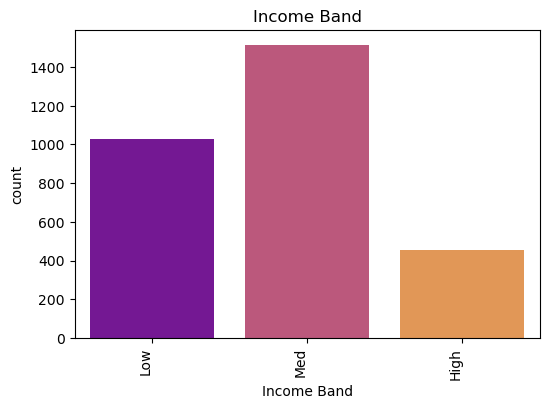

In [15]:
cat_cols = ['nationality','fee_structure','loyalty_classification',
            'amount_of_credit_cards','properties_owned','risk_weighting','brid',
            'genderid','iaid','Income Band']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col,palette='plasma')
    plt.title(col)
    plt.xticks(rotation=90, ha='right')
    plt.show()

BIVARIENT ANALYSIS

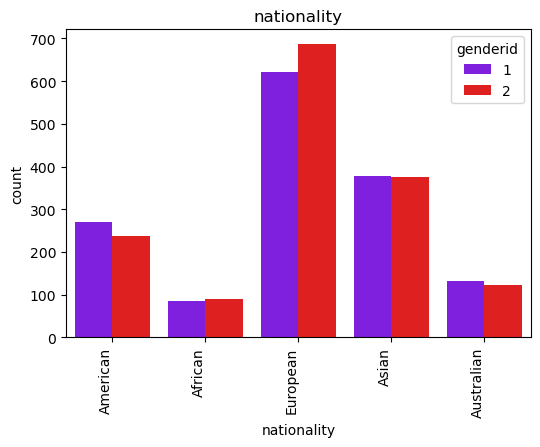

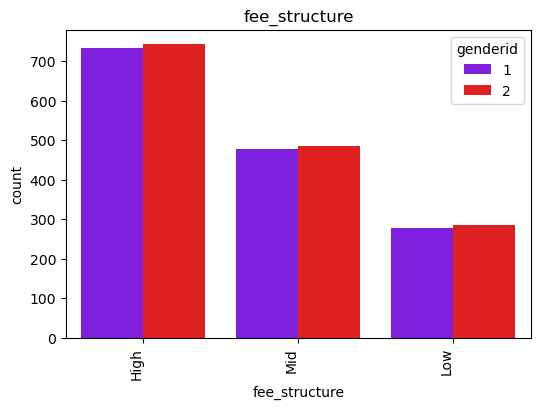

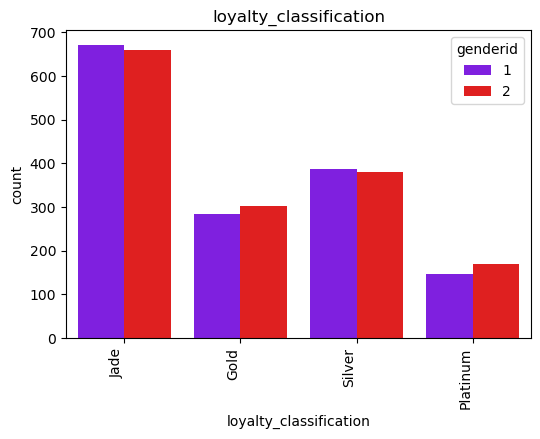

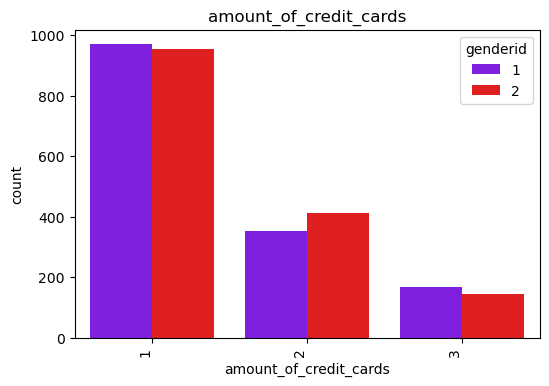

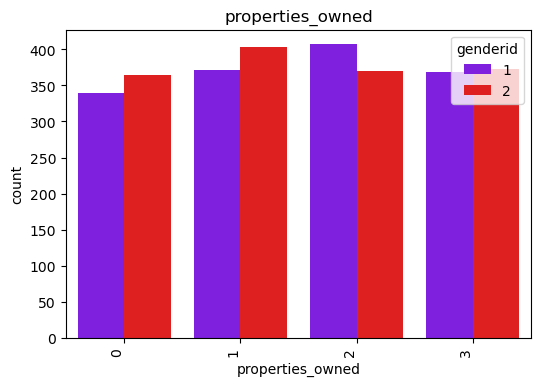

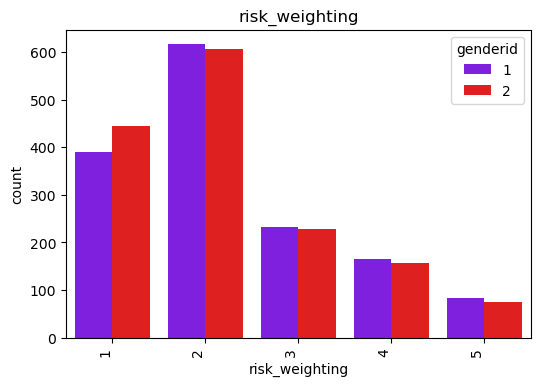

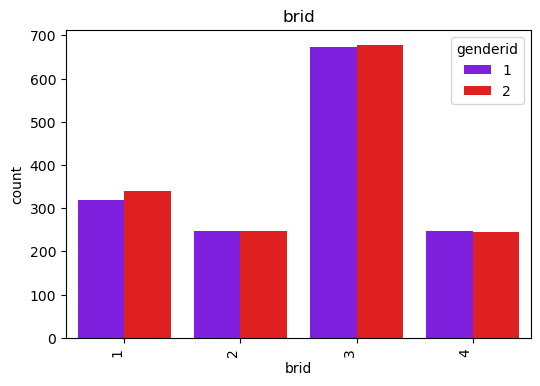

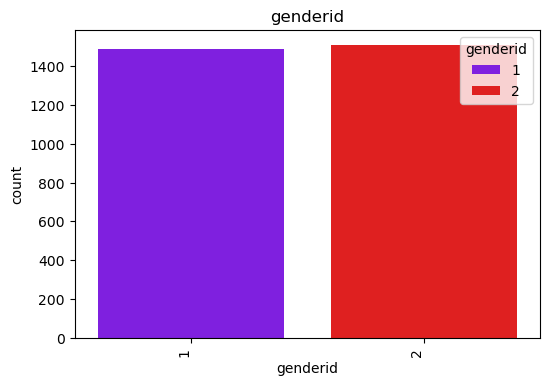

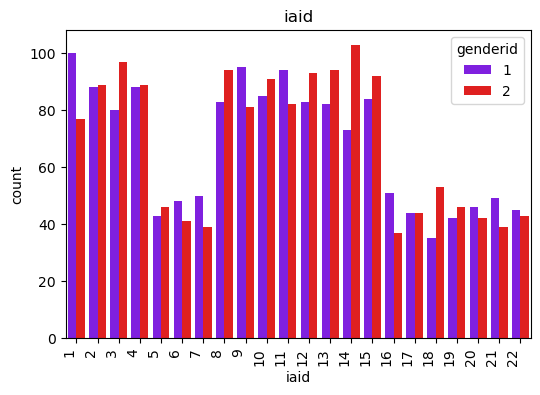

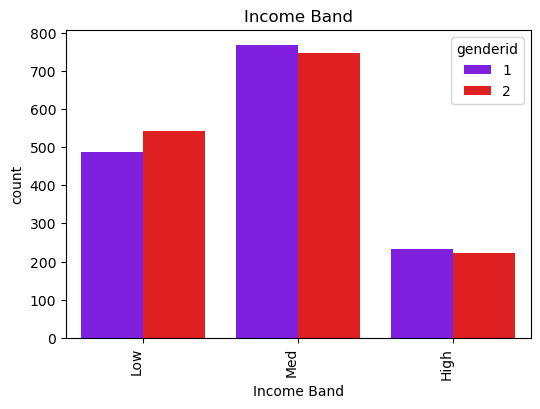

In [16]:

cat_cols = ['nationality','fee_structure','loyalty_classification',
            'amount_of_credit_cards','properties_owned','risk_weighting','brid',
            'genderid','iaid','Income Band']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col,hue='genderid',palette='rainbow')
    plt.title(col)
    plt.xticks(rotation=90, ha='right')
    plt.show()

HISTPLOT

In [17]:
df.columns

Index(['unnamed:_0', 'client_id', 'name', 'age', 'location_id', 'joined_bank',
       'banking_contact', 'nationality', 'occupation', 'fee_structure',
       'loyalty_classification', 'estimated_income', 'superannuation_savings',
       'amount_of_credit_cards', 'credit_card_balance', 'bank_loans',
       'bank_deposits', 'checking_accounts', 'saving_accounts',
       'foreign_currency_account', 'business_lending', 'properties_owned',
       'risk_weighting', 'brid', 'genderid', 'iaid', 'income_band',
       'Income Band'],
      dtype='object')

In [18]:
num_cols = ['estimated_income', 'superannuation_savings','credit_card_balance','bank_loans','bank_deposits','checking_accounts','saving_accounts','foreign_currency_account','business_lending']

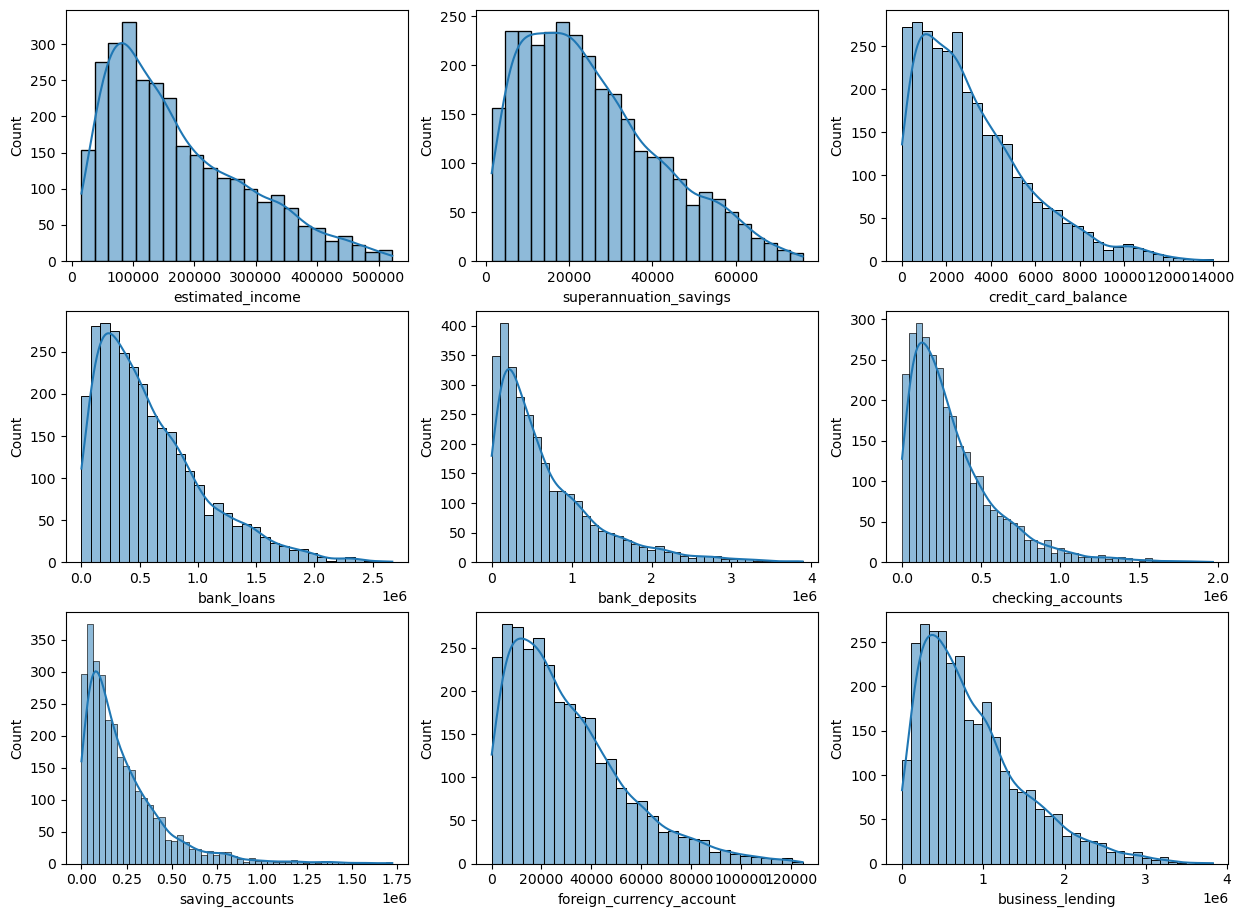

In [19]:
plt.figure(figsize=(15,15))
for i,col in enumerate(num_cols):
    plt.subplot(4,3,i+1)
    sns.histplot(df[col], kde=True)
    # plt.title(col)
plt.show()

HEATMAP

In [20]:
corr = df[num_cols].corr()

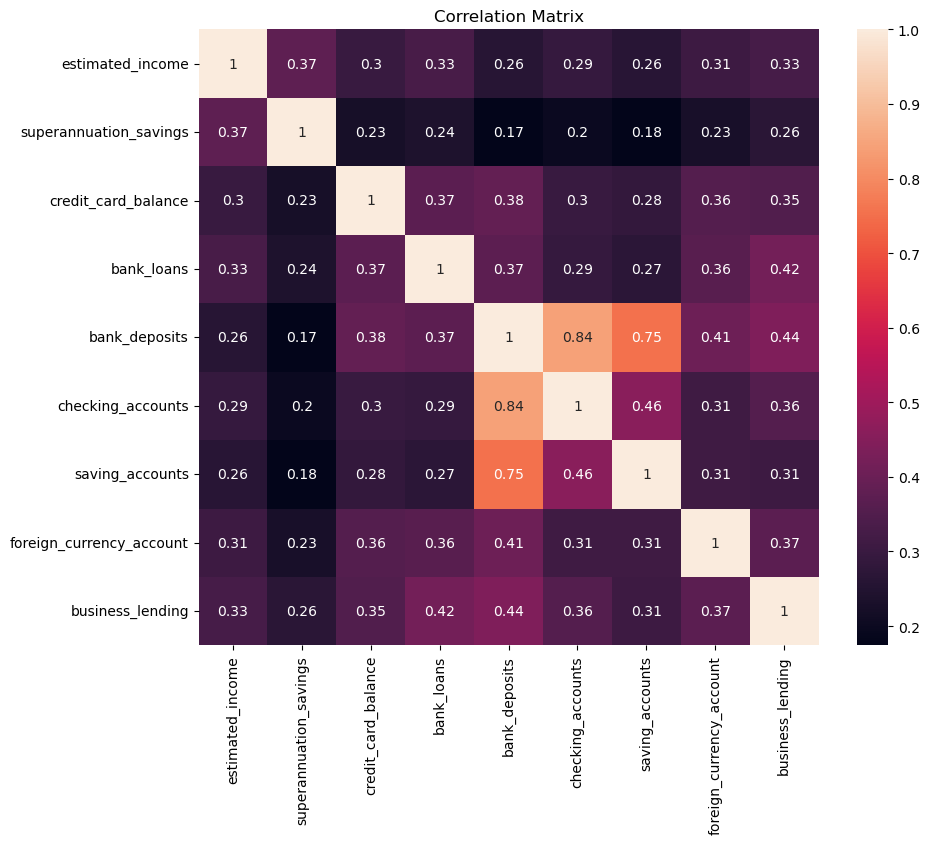

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True)
plt.title("Correlation Matrix")
plt.show()

INSIGHTS

Extract

In [22]:
df.to_csv("customers.csv")